In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Cargar el archivo CSV correctamente.

In [2]:
url ='https://raw.githubusercontent.com/KatiaMusun/parcial4-Katia-Musun-2524562022/refs/heads/main/archivos/clave_F_correlacion.csv'
df=pd.read_csv(url)
df.head()

,cliente_id,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
0,F-C0001,18,1184,6,63.55,7.05,1,2,20.42,344.76
1,F-C0002,32,1023,8,60.06,7.88,2,7,12.99,475.57
2,F-C0003,46,1231,9,61.11,7.22,1,5,23.16,554.42
3,F-C0004,48,783,4,37.37,5.69,4,4,26.98,233.89
4,F-C0005,31,1187,7,65.26,3.50,8,7,28.48,386.42


Identificar las variables numéricas del dataset.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cliente_id          246 non-null    object 
 1   edad                246 non-null    int64  
 2   ingresos_mensuales  246 non-null    int64  
 3   frecuencia_compra   246 non-null    int64  
 4   ticket_promedio     245 non-null    float64
 5   satisfaccion        245 non-null    float64
 6   reclamos            246 non-null    int64  
 7   uso_app             246 non-null    int64  
 8   tiempo_respuesta    245 non-null    float64
 9   consumo_total       246 non-null    float64
dtypes: float64(4), int64(5), object(1)
memory usage: 19.3+ KB


en el caso de esta base la mayoria de los campos son de tipo numerico menos Cliente_id que es de tipo objeto

Revisar datos nulos, valores atípicos y consistencia general.

In [4]:
df.isnull().sum()


,0
cliente_id,0
edad,0
ingresos_mensuales,0
frecuencia_compra,0
ticket_promedio,1
satisfaccion,1
reclamos,0
uso_app,0
tiempo_respuesta,1
consumo_total,0


la base cuenta con 3 datos nuelos en las columnas ticket_promedio, satisfaccion y tiempo_respuesta, dato que pueden afectar el analisi si eliminaron


In [5]:
df = df.dropna()
print(df.isnull().sum())

cliente_id            0
edad                  0
ingresos_mensuales    0
frecuencia_compra     0
ticket_promedio       0
satisfaccion          0
reclamos              0
uso_app               0
tiempo_respuesta      0
consumo_total         0
dtype: int64


In [6]:
df.describe()

,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
count,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000
mean,38.744856,1119.967078,7.938272,66.365761,7.519300,1.547325,5.658436,21.133745,526.909712
std,10.248197,264.150187,3.284118,15.403355,1.340144,1.755988,2.059698,6.755864,222.525764
min,18.000000,484.000000,2.000000,27.130000,3.020000,0.000000,0.000000,5.000000,161.130000
25%,31.000000,928.500000,6.000000,56.510000,6.785000,0.000000,4.000000,16.640000,381.965000
50%,39.000000,1117.000000,8.000000,66.150000,7.730000,1.000000,6.000000,20.580000,514.740000
75%,46.000000,1297.000000,9.000000,75.980000,8.510000,2.000000,7.000000,25.525000,628.070000
max,62.000000,1838.000000,32.000000,114.020000,10.000000,9.000000,10.000000,43.500000,2026.660000


In [7]:
df_numeric = df.select_dtypes(include=['number'])

In [8]:
variables_numericas = [
    "edad",
    "ingresos_mensuales",
    "frecuencia_compra",
    "ticket_promedio",
    "satisfaccion",
    "reclamos",
    "uso_app",
    "tiempo_respuesta",
    "consumo_total"
]

for columna in variables_numericas:


    media = df[columna].mean()
    desviacion = df[columna].std()


    limite_inferior = media - 2 * desviacion
    limite_superior = media + 2 * desviacion

    atipicos = df[
        (df[columna] < limite_inferior) |
        (df[columna] > limite_superior)
    ]


    print("Variable:", columna)
    print("Límite inferior:", round(limite_inferior, 2))
    print("Límite superior:", round(limite_superior, 2))
    print("Cantidad de atípicos:", len(atipicos))
    print("-" * 50)

Variable: edad
Límite inferior: 18.25
Límite superior: 59.24
Cantidad de atípicos: 10
--------------------------------------------------
Variable: ingresos_mensuales
Límite inferior: 591.67
Límite superior: 1648.27
Cantidad de atípicos: 13
--------------------------------------------------
Variable: frecuencia_compra
Límite inferior: 1.37
Límite superior: 14.51
Cantidad de atípicos: 3
--------------------------------------------------
Variable: ticket_promedio
Límite inferior: 35.56
Límite superior: 97.17
Cantidad de atípicos: 9
--------------------------------------------------
Variable: satisfaccion
Límite inferior: 4.84
Límite superior: 10.2
Cantidad de atípicos: 11
--------------------------------------------------
Variable: reclamos
Límite inferior: -1.96
Límite superior: 5.06
Cantidad de atípicos: 8
--------------------------------------------------
Variable: uso_app
Límite inferior: 1.54
Límite superior: 9.78
Cantidad de atípicos: 10
---------------------------------------------

Calcular la matriz de correlación.

In [9]:
matriz = df_numeric.corr()
matriz

,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
edad,1.000000,0.077985,0.077739,0.147115,-0.018842,0.047976,0.060848,0.018614,0.103888
ingresos_mensuales,0.077985,1.000000,0.053081,0.659198,-0.060619,0.005268,-0.058199,0.164047,0.310576
frecuencia_compra,0.077739,0.053081,1.000000,0.155146,0.128787,-0.072937,0.392115,-0.089080,0.895338
ticket_promedio,0.147115,0.659198,0.155146,1.000000,-0.028522,-0.012443,-0.022530,0.062149,0.517851
satisfaccion,-0.018842,-0.060619,0.128787,-0.028522,1.000000,-0.828539,0.245036,-0.618593,0.182200
reclamos,0.047976,0.005268,-0.072937,-0.012443,-0.828539,1.000000,-0.023504,0.614937,-0.144891
uso_app,0.060848,-0.058199,0.392115,-0.022530,0.245036,-0.023504,1.000000,-0.219077,0.385333
tiempo_respuesta,0.018614,0.164047,-0.089080,0.062149,-0.618593,0.614937,-0.219077,1.000000,-0.123317
consumo_total,0.103888,0.310576,0.895338,0.517851,0.182200,-0.144891,0.385333,-0.123317,1.000000


Crear un mapa de calor o gráfico de correlación.

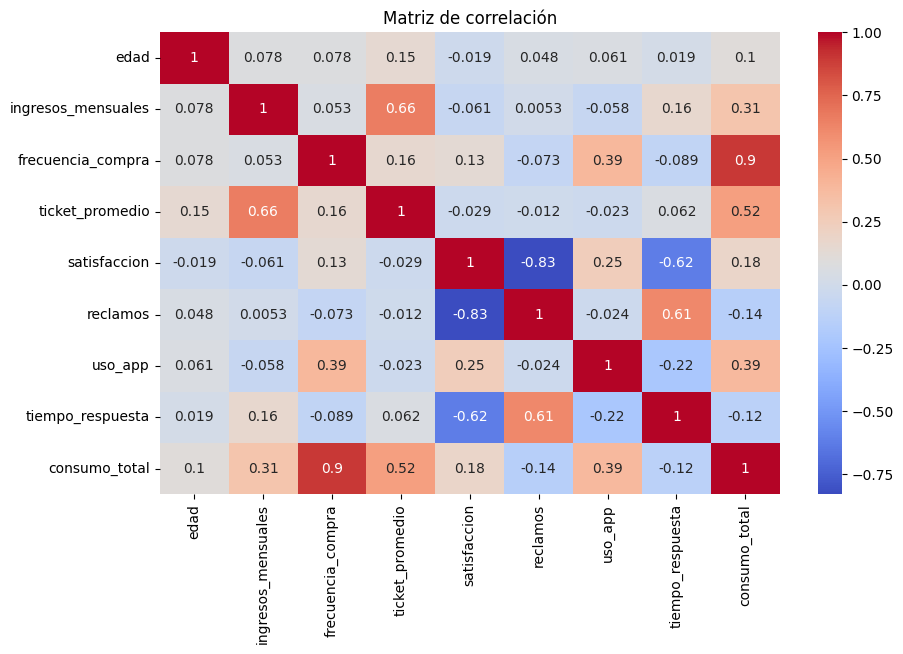

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(matriz, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()